In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('penguins_size.csv', delimiter=';')
df.drop(columns=['Unnamed: 6', 'Unnamed: 7'], inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    str    
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    str    
dtypes: float64(4), str(2)
memory usage: 16.4 KB


In [5]:
(1 - len(df.dropna()) / len(df)) * 100

2.8818443804034533

In [6]:
df.dropna(inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 337 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  337 non-null    str    
 1   Longitud Culmen (mm)     337 non-null    float64
 2   Profundidad Culmen (mm)  337 non-null    float64
 3   Longitud Aleta (mm)      337 non-null    float64
 4   Masa corporal (g)        337 non-null    float64
 5   Sexo                     337 non-null    str    
dtypes: float64(4), str(2)
memory usage: 18.4 KB


El dataset contiene datos nulos y al considerar que conforman menos de un 5% de nuestros datos podemos simplemente removerlos de nuestro dataset.

In [46]:
df['Sexo'].unique()
df[df['Sexo'] == '.']

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
339,Gentoo penguin,44.5,15.7,217.0,4875.0,.


In [7]:
df.drop(df[df['Sexo'] == '.'].index, inplace=True)
df.info()

<class 'pandas.DataFrame'>
Index: 336 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  336 non-null    str    
 1   Longitud Culmen (mm)     336 non-null    float64
 2   Profundidad Culmen (mm)  336 non-null    float64
 3   Longitud Aleta (mm)      336 non-null    float64
 4   Masa corporal (g)        336 non-null    float64
 5   Sexo                     336 non-null    str    
dtypes: float64(4), str(2)
memory usage: 18.4 KB


In [8]:
df['SexoCod'] = (df['Sexo'] == 'MALE').astype(int)
df

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,SexoCod
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE,1
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE,0
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE,0
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE,0
5,Adelie Penguin,39.3,20.6,190.0,3650.0,MALE,1
...,...,...,...,...,...,...,...
341,Gentoo penguin,47.2,13.7,214.0,4925.0,FEMALE,0
343,Gentoo penguin,46.8,14.3,215.0,4850.0,FEMALE,0
344,Gentoo penguin,50.4,15.7,222.0,5750.0,MALE,1
345,Gentoo penguin,45.2,14.8,212.0,5200.0,FEMALE,0


In [9]:
df.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),SexoCod
count,336.000000,336.000000,336.000000,336.000000,336.000000
mean,44.015179,17.168750,200.997024,4209.300595,0.505952
std,5.520019,1.961375,14.061804,809.547157,0.500710
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.450000,15.600000,190.000000,3550.000000,0.000000
50%,44.450000,17.300000,197.000000,4050.000000,1.000000
75%,48.625000,18.700000,213.000000,4781.250000,1.000000
max,59.600000,21.500000,231.000000,6300.000000,1.000000


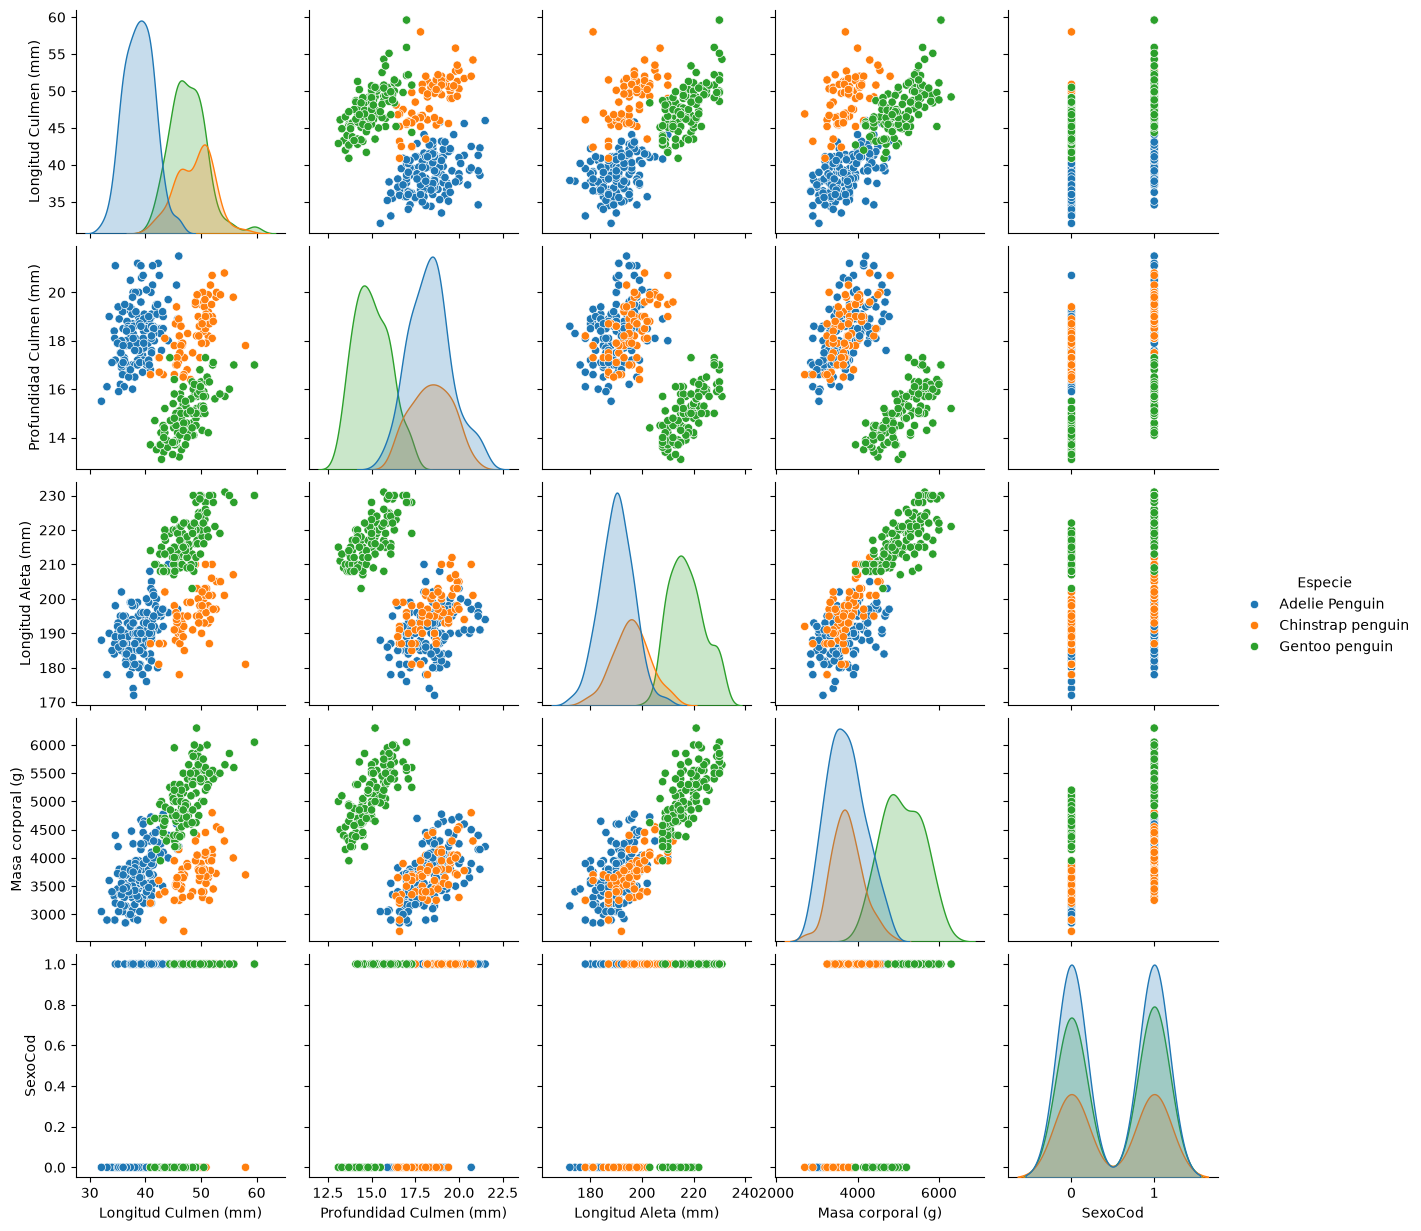

In [55]:
sns.pairplot(df, hue='Especie', diag_kind='kde')

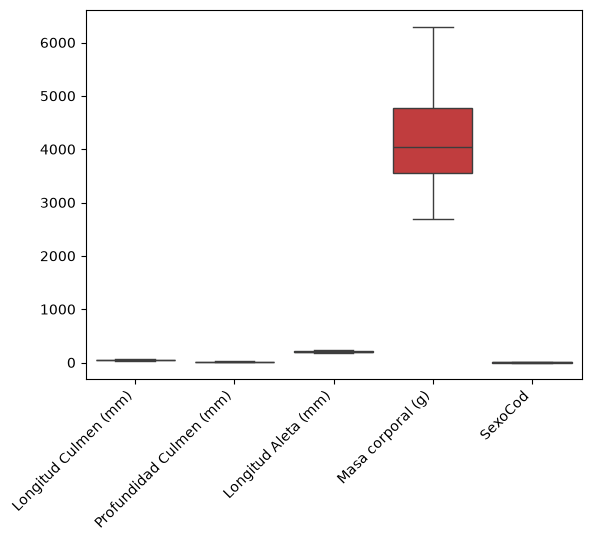

In [57]:
sns.boxplot(df)
plt.xticks(rotation=45, ha="right")
plt.show()

Por mas que no se vea demasiado, se puede apreciar la ausencia de outliers.

In [ ]:
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA().set_output(transform="pandas"))
])

df_pca = pca_pipeline.fit_transform(df[num_columns])